In [25]:
from torch.utils.data import Dataset, DataLoader, random_split
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt

In [26]:
class CustomDataset(Dataset):
    def __init__(self, images, labels=None, transform=None):
        self.images    = images
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]

        if self.transform:
            img = self.transform(img)

        if self.labels is not None:
            return img, int(self.labels[idx])

        return img

In [27]:
with open('../datasets/mnist.pkl', 'rb') as f:
  u = pkl._Unpickler(f)
  u.encoding = 'latin1'
  data = u.load()

print(data)
# 50000, 10000, 10000개 shape로 나누어지므로 -> train, val, test (5:1:1)

((array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(50000, 784), dtype=float32), array([5, 0, 4, ..., 8, 4, 8], shape=(50000,))), (array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 784), dtype=float32), array([3, 8, 6, ..., 5, 6, 8], shape=(10000,))), (array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 784), dtype=float32), array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))))


In [28]:
(x_train, y_train), (x_val, y_val), (x_test, y_test) = data

In [29]:
train_dataset = CustomDataset(x_train, y_train)
test_dataset = CustomDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [30]:
print(len(train_dataset), len(test_dataset))

50000 10000


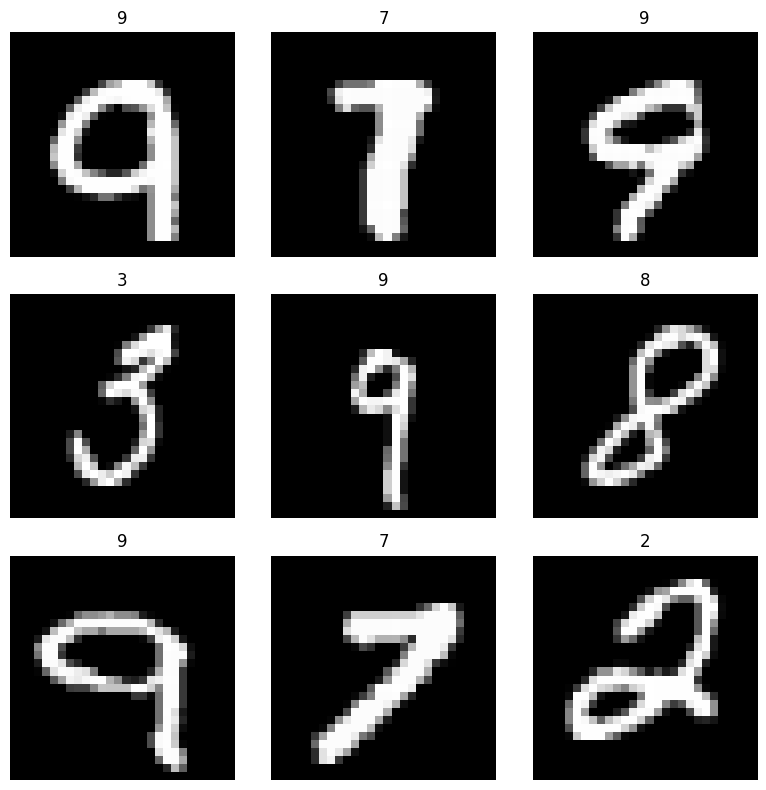

In [41]:
CLASSES = tuple(str(i) for i in range(10))

indices = np.random.choice(len(train_dataset), 9, replace=False)

figure = plt.figure(figsize=(8, 8))

for i, idx in enumerate(indices, 1):
    img, label = train_dataset[idx]
    figure.add_subplot(3, 3, i)
    plt.title(CLASSES[label])
    plt.axis(False)
    plt.imshow(img.reshape(28, 28), cmap="gray")

plt.tight_layout()
plt.show()